In [1]:
#导入对应的模块
import os
import pandasai as pai
from pandasai_litellm import LiteLLM
from pandasai.agent import Agent

In [2]:
#将deepseek的api导入到环境变量并设置模型
os.environ["DEEPSEEK_API_KEY"]="sk-578f63b08e74438692e3ebdb42b49934"
llm = LiteLLM(
    model="deepseek/deepseek-chat",
    stream=False
)
pai.config.set({"llm":llm})

In [3]:
# 创建示例DataFrame
        
df = pai.DataFrame({
    "country": ["United States", "United Kingdom", "France", "Germany", "Italy", "Spain", "Canada", "Australia", "Japan", "China"],
    "revenue": [5000, 3200, 2900, 4100, 2300, 2100, 2500, 2600, 4500, 7000]
})

In [4]:
# 创建Agent实例
agent = Agent([df])

In [5]:
# 定义问题
question = "Plot the histogram of countries showing for each one the gd. Use different colors for each bar"

In [6]:
# 生成代码并获取提示
code = agent.generate_code(question)


In [7]:
# 获取最新使用的提示
prompt = agent._state.last_prompt_used

# 打印提示内容
print(prompt.render())

<tables>

<table dialect="duckdb" table_name="table_3196ce98cf3ce3223735e1d61022e9d2" columns="[{"name": "country", "type": "string", "description": null, "expression": null, "alias": null}, {"name": "revenue", "type": "integer", "description": null, "expression": null, "alias": null}]" dimensions="10x2">
country,revenue
United States,5000
United Kingdom,3200
France,2900
Germany,4100
Italy,2300
</table>

</tables>

You are already provided with the following functions that you can call:
<function>
def execute_sql_query(sql_query: str) -> pd.Dataframe
    """This method connects to the database, executes the sql query and returns the dataframe"""
</function>

Update this initial code:
```python
# TODO: import the required dependencies
import pandas as pd

# Write code here

# Declare result var: 
type (possible values "string", "number", "dataframe", "plot"). Examples: { "type": "string", "value": f"The highest salary is {highest_salary}." } or { "type": "number", "value": 125 } or { "t

In [8]:
# 提问
response = df.chat(
    "Plot the histogram of countries showing for each one the gd. Use different colors for each bar",
)
print(response)

exports\charts\temp_chart_8ee3074f-9cd2-44af-ac6d-44ec3cede2dd.png


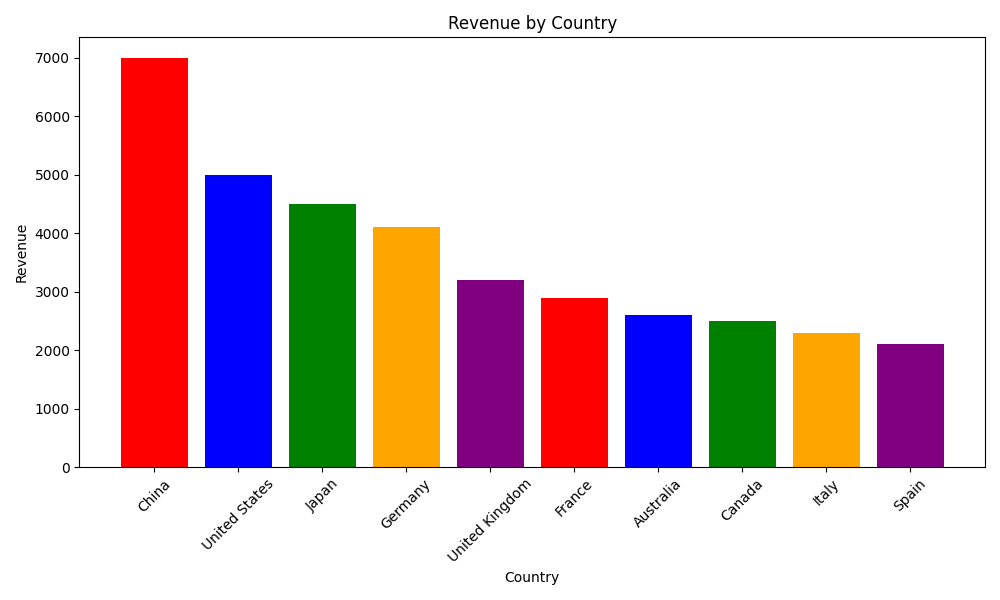

In [10]:
#问题2：销售额排名前五的国家
response2=df.chat('Which are the top 5 countries by sales?')
print(response2)

          country  revenue
0           China     7000
1   United States     5000
2           Japan     4500
3         Germany     4100
4  United Kingdom     3200


In [11]:
#问题2的prompt
# 定义问题
question = "Which are the top 5 countries by sales?"

# 生成代码并获取提示
code = agent.generate_code(question)

# 获取最新使用的提示
prompt = agent._state.last_prompt_used

# 打印提示内容
print(prompt.render())

<tables>

<table dialect="duckdb" table_name="table_3196ce98cf3ce3223735e1d61022e9d2" columns="[{"name": "country", "type": "string", "description": null, "expression": null, "alias": null}, {"name": "revenue", "type": "integer", "description": null, "expression": null, "alias": null}]" dimensions="10x2">
country,revenue
United States,5000
United Kingdom,3200
France,2900
Germany,4100
Italy,2300
</table>

</tables>

You are already provided with the following functions that you can call:
<function>
def execute_sql_query(sql_query: str) -> pd.Dataframe
    """This method connects to the database, executes the sql query and returns the dataframe"""
</function>

Update this initial code:
```python
# TODO: import the required dependencies
import pandas as pd

# Write code here

# Declare result var: 
type (possible values "string", "number", "dataframe", "plot"). Examples: { "type": "string", "value": f"The highest salary is {highest_salary}." } or { "type": "number", "value": 125 } or { "t

In [12]:
#问题3（稍微难一点的问题）：前三国家的销售总和
response3=df.chat(
    "What is the total sales for the top 3 countries by sales?"
)
print(response3)

16500.0


In [13]:
#问题3的prompt
# 定义问题
question3 = "What is the total sales for the top 3 countries by sales?"

# 生成代码并获取提示
code = agent.generate_code(question3)

# 获取最新使用的提示
prompt = agent._state.last_prompt_used

# 打印提示内容
print(prompt.render())

<tables>

<table dialect="duckdb" table_name="table_3196ce98cf3ce3223735e1d61022e9d2" columns="[{"name": "country", "type": "string", "description": null, "expression": null, "alias": null}, {"name": "revenue", "type": "integer", "description": null, "expression": null, "alias": null}]" dimensions="10x2">
country,revenue
United States,5000
United Kingdom,3200
France,2900
Germany,4100
Italy,2300
</table>

</tables>

You are already provided with the following functions that you can call:
<function>
def execute_sql_query(sql_query: str) -> pd.Dataframe
    """This method connects to the database, executes the sql query and returns the dataframe"""
</function>

Update this initial code:
```python
# TODO: import the required dependencies
import pandas as pd

# Write code here

# Declare result var: 
type (possible values "string", "number", "dataframe", "plot"). Examples: { "type": "string", "value": f"The highest salary is {highest_salary}." } or { "type": "number", "value": 125 } or { "t

上述三个问题的答案均正确。
